# Đồ án nhận diện tin giả bằng mô hình học máy

## import các thư viện để sử dụng

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.metrics import Precision, Recall
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

import re
import joblib
from sklearn.model_selection import train_test_split
from underthesea import word_tokenize
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier

In [2]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")
warnings.filterwarnings("ignore", category=Warning, module="tensorflow")

## Data description:
**Bộ dữ liệu được lấy từ nguồn:** Các trang báo của việt nam
***
Dataset trong file **data_train.csv** và **data_test.csv** có 4 đặc trưng là:
- `title` : Tựa đề của bài báo.
- `text`  : Nội dung bài báo.
- `author`: Tên tác giả.
- `source_domain`: Domain lấy tin.
- `label` : Tính đáng tin cậy.
***
Đặc trưng `label` có vai trò là target của mô hình dự đoán. Đặc trưng này mang 2 giá trị biểu diễn độ đáng tin cậy của bài báo:
* 1: tin giả (không đáng tin)
* 0: tin thật (đáng tin)
***

In [3]:
Data = pd.read_csv('data_train.csv', encoding = 'utf-8')
features = Data.columns.to_list()[:-1]
print(Data.shape)
print(features)

(1395, 5)
['title', 'text', 'author', 'source_domain']


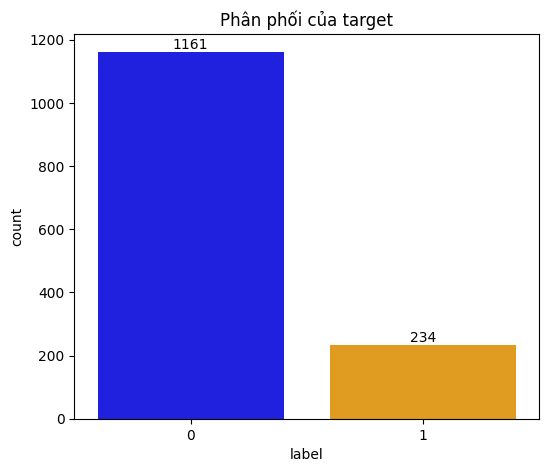

In [4]:
def plot_target(data, title):
    target_counts = data.value_counts('label').reset_index()  # Reset chỉ mục để có dataframe
    target_counts.columns = ['label', 'count']  # Đặt tên cột
    
    plt.figure(figsize=(6,5))
    
    # Vẽ biểu đồ với hue là cột 'label' để không nhận cảnh báo
    ax = sns.barplot(x='label', y='count', hue='label', data=target_counts, 
                     palette={0: 'blue', 1: 'orange'}, legend=False)
    
    ax.set_title(title)
    
    # Hiển thị giá trị của từng cột
    for i in ax.containers:
        ax.bar_label(i)
    
    plt.show()

# Ví dụ sử dụng
plot_target(Data, 'Phân phối của target')


## Text preprocessing

* Xem qua một vài instace để có một cái nhìn cơ bản về dataset

In [5]:
Data.head(10)

,title,text,author,source_domain,label
0,Con gái chính là người tình kiếp trước của cha...,"Thế nhưng, dù không nói ra thì cha vĩnh viễn l...",NaN,2sao.vn,1
1,Thủ tướng Abe cúi đầu xin lỗi vì hành động phi...,"Theo Sankei Sports, sáng nay Thủ tướng Nhật Bả...",Văn Trình,binhluan.biz,1
2,Thủ tướng Nhật cúi đầu xin lỗi vì tinh thần ph...,"Sáng 19/6, Thủ tướng Nhật Bản Shinzo Abe công ...","Cùng Tác Giả, Nguyễn Thiện",www.ipick.vn,1
3,Choáng! Cơ trưởng đeo khăn quàng quẩy banh nóc...,Xót xa hình ảnh thầy trò lội bùn băng rừng đến...,NaN,tintucqpvn.net,1
4,Chưa bao giờ nhạc Kpop lại dễ hát đến thế!!!,Giáo sư Nguyễn Lân Dũng: ‘Con tôi thành đạt nh...,NaN,tintucqpvn.net,1
5,"Đại học Hutech sẽ áp dụng cải cách ""Tiếq Việt""...","Mới đây, ông Phạm Ngọc Thanh, Phó giám đốc Sở ...",Gioi Tre Viet,www.gioitreviet.net,1
6,"Cười vỡ bụng khi tiếng CẢI CÁCH ""vuông tròn"" x...","Những ngày qua, các phụ huynh liên tục chia sẻ...",Please Enter Your Name Here,giadinhtiepthi.com,1
7,Chia sẻ thẳng thắn vụ việc 25000 USD và cải cá...,"Những ngày qua, trên mạng xã hội các phụ huynh...",Please Enter Your Name Here,giadinhtiepthi.com,1
8,Hại não với Vọng Cổ mang tên Vuông Tròn Tam Giác!,Chương trình công nghệ giáo dục: Hãy tôn trọng...,NaN,tintucqpvn.net,1
9,"Kinh hoàng bé gái bị chó nhà tấn công, cắn vào...","“Sẽ cấm tiệt, không cho mang chó vào phố đi bộ...",NaN,tintucqpvn.net,1


In [6]:
Data.sample(10)

,title,text,author,source_domain,label
278,"5 xe tông liên hoàn, cao tốc Dầu Giây - Phan T...",Đồng NaiTai nạn liên hoàn giữa 5 ôtô khiến cao...,Phước Tuấn,vnexpress.net,0
873,Đề nghị cho phép bán thuốc qua mạng với trường...,"Dự án Luật sửa đổi, bổ sung một số điều của Lu...",Hoài Thu,dantri.com.vn,0
765,Ông Trần Duy Đông được bầu làm Chủ tịch UBND t...,"Ông Trần Duy Đông, Phó bí thư Tỉnh ủy Vĩnh Phú...",Phạm Dự,vnexpress.net,0
1273,Bổ nhiệm Bí thư Ban cán sự Đảng UBND tỉnh Gia Lai,Lãnh đạo tỉnh Gia Lai tặng hoa chúc mừng ông R...,Tiền Lê,baomoi.com,0
578,Ông Triệu Thế Hùng thôi làm Chủ tịch UBND tỉnh...,"Sáng 12/8, HĐND tỉnh Hải Dương thông qua nghị ...",Lê Tân,vnexpress.net,0
336,Ba nam sinh nhận huy hiệu Tuổi trẻ dũng cảm vì...,"Hà TĩnhBa nam sinh lớp 8 Nguyễn Thành Công, Ng...",Đức Hùng,vnexpress.net,0
1244,Việt Nam chuyển giao vai trò Chủ tịch Ủy ban A...,"Các Đại sứ, Đại biện và cán bộ Đại sứ quán các...",Nguyễn Thu Hà (P/v TTXVN tại Paris),baomoi.com,0
633,Đề xuất sinh viên được làm thêm 24 tiếng mỗi tuần,Bộ Lao động Thương binh và Xã hội nâng đề xuất...,Hồng Chiêu,vnexpress.net,0
1301,"Lào Cai: Nguồn cung hàng hóa dồi dào, đảm bảo ...",Các sạp hàng rau xanh tại chợ dân sinh trên đị...,Đức Phương,baomoi.com,0
158,Vì sao ông Lưu Bình Nhưỡng bị bắt?,"Sáng 15/11, đồng loạt nhiều tờ báo đưa tin ông...",Youtube Việt Tân,viettan.org,1


### Xem thông tin

In [7]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1395 entries, 0 to 1394
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          1395 non-null   object
 1   text           1395 non-null   object
 2   author         1234 non-null   object
 3   source_domain  1395 non-null   object
 4   label          1395 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 54.6+ KB


### Xem mô tả

In [8]:
Data.describe().round(1)

,label
count,1395.0
mean,0.2
std,0.4
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,1.0


### Xem số dòng và số cột của dữ liệu

In [9]:
num_rows=Data.shape[0]
num_cols=Data.shape[1]
print(num_rows)
print(num_cols)

1395
5


### Ý nghĩa các dòng

#### Kiểm tra dữ liệu có bị lặp

In [10]:
duplicate = Data.index.duplicated().sum()
duplicate

0

### Mỗi cột hiện đang có kiểu dữ liệu gì? Có cột nào có kiểu dữ liệu chưa phù hợp để có thể xử lý tiếp không?

In [11]:
Data.dtypes

title            object
text             object
author           object
source_domain    object
label             int64
dtype: object

#### Cột có dtype là object nghĩa là sao?
- Trong Pandas, kiểu dữ liệu object thường ám chỉ chuỗi, nhưng thật ra kiểu dữ liệu object có thể chứa một đối tượng bất kỳ trong Python (vì thật ra ở bên dưới kiểu dữ liệu object chứa địa chỉ).
- Nếu một cột trong dataframe có dtype là object thì có thể các phần tử trong cột này sẽ có kiểu dữ liệu khác nhau
- Để biết được kiểu dữ liệu thật sự của các phần tử trong cột này thì ta phải truy xuất vào từng phần tử. Ta muốn xem thử trong nội bộ mỗi cột này có các kiểu dữ liệu nào

In [12]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [13]:
open_object_dtype(Data['title'])

{str}

In [14]:
open_object_dtype(Data['text'])

{str}

In [15]:
open_object_dtype(Data['author'])

{float, str}

In [16]:
open_object_dtype(Data['source_domain'])

{str}

#### Các thông tin thống kê

##### Chiều dài trung bình mỗi record là bao nhiêu?

In [17]:
len_sum=0
for i in Data['text']:
    len_sum+=len(i)
len_avg=len_sum/Data['text'].count()
len_avg

2892.689605734767

##### Record dài nhất là bao nhiêu?

In [18]:
max_len=0
for i in Data['text']:
    if len(i)>max_len:
        max_len=len(i)
max_len

33691

##### Record ngắn nhất là bao nhiêu?

In [19]:
min_len=len(Data['text'][0])
for i in Data['text']:
    if len(i)<min_len:
        min_len=len(i)
min_len

10

##### Tin tức được thu thập từ trang web nào nhiều nhất?

In [20]:
Data['source_domain'].value_counts()

source_domain
vnexpress.net             586
dantri.com.vn             171
vietnamnet.vn             140
baomoi.com                118
viettan.org               103
thanhnien.vn               80
tinvn.info                 68
nhandan.vn                 45
tuoitre.vn                 21
thoibao.today               6
tintucqpvn.net              5
www.webtretho.com           4
anninh247.xyz               4
phapluat.news               3
baophapluat.online          3
giadinhtiepthi.com          2
thoibao.de                  2
congtintuc24gio.com         2
www.ipick.vn                2
thegioitre.vn               2
danviet.vn                  2
soha.vn                     1
kenh14.vn                   1
trumpandq.blogspot.com      1
lichngaytot.com             1
tuvanannam.com              1
blogxcy.wordpress.com       1
shopjaxvinhphuc.vn          1
tintuconline.com.vn         1
2sao.vn                     1
nuochoauk.vn                1
sorry.vn                    1
www.gioitreviet.net       

### Dữ liệu bị miss

In [21]:
print("Dữ liệu bị miss")
for col in Data.columns:
    print(f"{col:<20}  {np.sum(pd.isnull(Data[col]))}")

Dữ liệu bị miss
title                 0
text                  0
author                161
source_domain         0
label                 0


Ta nhận thấy một số điểm sau:
- Đặc trưng `author` có một số giá trị bị thiếu. Đối với xử lý ngôn ngữ tự nhiên, ta có thể mặc định đây là những ký tự trống (''). 
   >Tuy nhiên, xét trên ngữ cảnh của bài toán phân loại tin giả, mối tương quan giữa việc không biết rõ tác giả với tính xác thực của bài báo là đáng quan tâm. <br>
&rarr;Vậy nên, ta cần quan sát thêm về mối tương quan giữa những giá trị bị thiếu này (`author`) đối với đặc trưng `target`.
- Bộ dữ liệu chứa nhiều ký tự đặc biệt không có ích cho quá trình dự đoán như `./>-` cần phải được loại bỏ.
- Các chữ cái viết hoa và viết thường không khác biệt nhau về nghĩa.

#### Author bị miss và xử lý

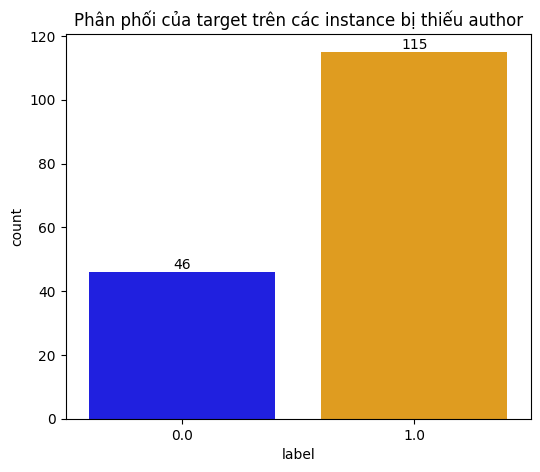

In [23]:
# đánh giá về phân bố của những instance có đặc trưng author bị thiếu.
observe_data = Data.where(Data['author'].isnull())
plot_target(observe_data, 'Phân phối của target trên các instance bị thiếu author')

&rarr; Vậy là luận điểm của em đã phần nào được chứng minh khi gần như toàn bộ những bài báo không rõ tác giả đều không đáng tin cậy. Dựa trên kinh nghiệm của bản thân, em sẽ impute những giá trị thiếu ở đặc trưng author là ***anonymousauthor*** để đảm bảo chúng được mô hình xem xét như một từ độc lập.

### Text cleaning

In [24]:
# Cài đặt một hàm để xử lý dữ liệu bị thiếu.
def handle_missing_values(data):
    newdata = pd.DataFrame()
    newdata['author'] = data['author'].fillna('anonymousauthor')
    cols = ['title', 'text']
    for i in cols:
        newdata[i] = data[i].fillna('')
    return newdata
        
# Cài đặt một hàm để đưa các chữ cái trong dữ liệu về chung dạng viết thường.
def lowcase_data(data):
    newdata = data.copy()
    for col in features:
        newdata[col] = data[col].str.lower()
    return newdata

# Cài đặt một hàm để loại bỏ những ký tự không phải chữ cái.
def remove_punctuations(text):
    x = re.sub(r'[^a-z ]', '',text)
    return ''.join(x)

- Xử lý missing values

In [25]:
cleaned_data = handle_missing_values(Data)
# gán lại Target cho tập train.
cleaned_data['label'] = Data['label']

In [26]:
print("Missing values counter on data")
for col in cleaned_data.columns:
    print(f"{col:<20}  {np.sum(pd.isnull(cleaned_data[col]))}")

Missing values counter on data
author                0
title                 0
text                  0
label                 0
